# 🏬 Walmart Sales Analysis - Quick Start Guide

## 📌 Contexte du Projet

**Objectif principal** : Prédire les ventes hebdomadaires (`Weekly_Sales`) des magasins Walmart

**Dataset** : Walmart Store Sales (Kaggle)
- **Période** : 2010-2012
- **Granularité** : Données hebdomadaires par magasin
- **Nombre de magasins** : Multiples stores

**Approche ML** :
- Type : Régression (prédiction de valeurs continues)
- Train/Test split : Basé sur le temps (train: 2010-2011, test: 2012)
- Features : Indicateurs économiques + features temporelles

---

## 📋 Structure du Notebook

1. **Imports & Chargement des données**
2. **Exploration de la structure** (`df.info()`)
3. **Preprocessing : Conversion des dates**
4. **Feature Engineering : Extraction des composantes temporelles**
5. **Visualisation : Analyse des ventes par année**
6. **Visualisation : Analyse de la saisonnalité (par mois)**
7. **Statistiques descriptives**

---

**Auteur** : Votre équipe data  
**Date** : Février 2026  
**Version** : 1.0

## 📦 Étape 1 : Imports & Chargement des Données

**Librairies utilisées** :
- **pandas** : Manipulation et analyse des données tabulaires
- **matplotlib.pyplot** : Visualisation de base
- **seaborn** : Visualisations statistiques avancées et plus esthétiques

**Chargement du dataset** :
- **Fichier** : `Walmart.csv`
- **Localisation** : `../data/raw/Walmart.csv`
- **Format** : CSV (Comma-Separated Values)

**Première vérification** :
- Affichage du nombre de lignes (records)
- Comptage des magasins uniques
- Liste des colonnes disponibles
- Aperçu des premières lignes avec `.head()`

In [20]:
# Load data for ALL stores
# Cellule 1 - À exécuter en premier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Correct path: data/raw/Walmart.csv
df = pd.read_csv('../data/raw/Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 465.2 KB


## 📋 Étape 2 : Exploration de la Structure des Données

**Objectif** : Comprendre la structure du dataset avant l'analyse

**Actions** :
- Afficher les types de colonnes (int, float, object)
- Vérifier le nombre de lignes et colonnes
- Identifier les valeurs manquantes potentielles
- Voir la mémoire utilisée par le dataframe

**Pourquoi c'est important ?**  
Connaître les types de données nous aide à :
- Détecter si certaines colonnes doivent être converties (ex: Date en datetime)
- Identifier les problèmes de qualité des données
- Planifier les transformations nécessaires

In [25]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[us]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.3 KB


## 📅 Étape 3 : Conversion de la Colonne Date

**Problème détecté** : La colonne `Date` est de type `object` (texte) au lieu de `datetime`

**Solution** : Convertir en format datetime avec `pd.to_datetime()`

**Format de la date** : `'%d-%m-%Y'` (jour-mois-année)
- Exemple : `05-02-2010` = 5 février 2010

**Pourquoi cette conversion ?**
- ✅ Permet d'extraire année, mois, semaine facilement
- ✅ Permet de filtrer par période (train/test split)
- ✅ Permet de faire des analyses temporelles (séries chronologiques)
- ✅ Améliore les performances des opérations sur les dates

In [26]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['week_of_year'] = df['Date'].dt.isocalendar().week
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,week_of_year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


## 🔧 Étape 4 : Feature Engineering - Extraction des Composantes Temporelles

**Objectif** : Créer de nouvelles features (caractéristiques) à partir de la date

**Features créées** :
1. **`Year`** : Année (2010, 2011, 2012)
   - Utile pour : Identifier les tendances annuelles
   
2. **`Month`** : Mois (1 à 12)
   - Utile pour : Détecter la saisonnalité (ex: ventes élevées en décembre)
   
3. **`week_of_year`** : Numéro de la semaine dans l'année (1 à 52)
   - Utile pour : Analyse des patterns hebdomadaires
   
**Pourquoi c'est important pour notre modèle ML ?**
- Les modèles ML ne comprennent pas les dates directement
- Ces features permettent au modèle de capturer :
  - Les tendances temporelles (croissance année après année)
  - Les patterns saisonniers (Noël, rentrée scolaire, etc.)
  - Les cycles hebdomadaires

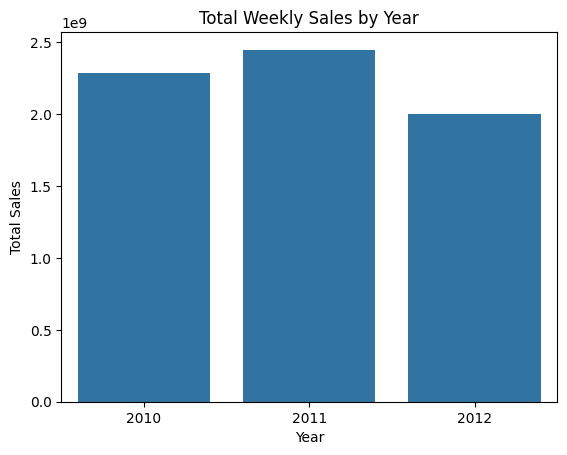

In [ ]:
totale_seles_stores = df['Weekly_Sales'].sum()
# Calcule les ventes hebdomadaires totales par année
totale_by_date = df.groupby('Year', as_index=False)['Weekly_Sales'].sum()

ax = sns.barplot(
    data=totale_by_date,
    x='Year',
    y='Weekly_Sales'
)
ax.set_title('Total Weekly Sales by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales')

plt.xticks(rotation=0)
plt.show()


## 📊 Étape 5 : Visualisation des Ventes Totales par Année

**Objectif** : Analyser l'évolution des ventes au fil des années

**Méthodologie** :
1. **Calcul du total** : `df['Weekly_Sales'].sum()` → Ventes totales tous stores confondus
2. **Agrégation par année** : `groupby('Year')` → Regrouper par année
3. **Somme des ventes** : `.sum()` → Additionner toutes les ventes de chaque année

**Visualisation** :
- Type : Graphique en barres (barplot)
- Librairie : Seaborn (plus esthétique que matplotlib)
- Axes : 
  - X = Année
  - Y = Total des ventes hebdomadaires

**Questions à répondre** :
- ✅ Les ventes augmentent-elles ou diminuent-elles ?
- ✅ Y a-t-il des années exceptionnelles ?
- ✅ Quelle est la tendance générale ?

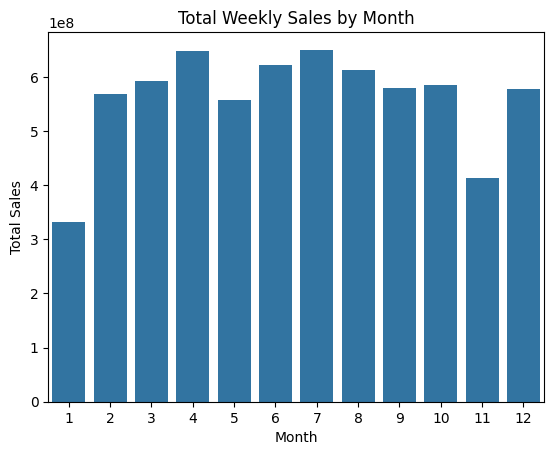

In [41]:
totale_seles_stores = df['Weekly_Sales'].sum()
# Calcule les ventes hebdomadaires totales par mois
totale_by_date = df.groupby('Month', as_index=False)['Weekly_Sales'].sum()

ax = sns.barplot(
    data=totale_by_date,
    x='Month',
    y='Weekly_Sales'
)
ax.set_title('Total Weekly Sales by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')

plt.xticks(rotation=0)
plt.show()


## 📈 Étape 6 : Visualisation des Ventes Totales par Mois

**Objectif** : Identifier la **saisonnalité** des ventes (patterns mensuels)

**Méthodologie** :
1. **Agrégation par mois** : `groupby('Month')` → Regrouper par mois (1-12)
2. **Somme des ventes** : Additionner toutes les ventes de chaque mois sur toutes les années

**Visualisation** :
- Type : Graphique en barres (barplot)
- Axes :
  - X = Mois (1=Janvier, 2=Février, ..., 12=Décembre)
  - Y = Total des ventes

**Insights attendus** :
- 🎄 **Décembre** : Généralement le mois le plus fort (fêtes de fin d'année)
- 📚 **Août/Septembre** : Forte activité (rentrée scolaire)
- 🏖️ **Janvier/Février** : Creux après les fêtes
- 🎃 **Octobre/Novembre** : Halloween et préparation de Noël

**Utilité pour le ML** :
Cette analyse nous aide à comprendre si notre modèle devra capturer ces patterns saisonniers. On pourra potentiellement créer une feature `is_holiday_season` pour booster les performances.

In [42]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,week_of_year
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.0
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552,25.818182
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000,1.0
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000,14.0
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000,26.0
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000,38.0
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000,52.0
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308,14.129201


## 📊 Étape 7 : Statistiques Descriptives Complètes

**Objectif** : Obtenir un résumé statistique de toutes les colonnes numériques

**Méthode** : `df.describe()` - Génère automatiquement :

**Pour chaque colonne numérique, on obtient** :
- **count** : Nombre de valeurs non-nulles
- **mean** : Moyenne (valeur centrale)
- **std** : Écart-type (mesure de dispersion)
- **min** : Valeur minimale
- **25%** : 1er quartile (25% des données sont en-dessous)
- **50%** : Médiane (valeur centrale, 50% au-dessus, 50% en-dessous)
- **75%** : 3ème quartile (75% des données sont en-dessous)
- **max** : Valeur maximale

**Colonnes analysées** :
- `Store` : ID du magasin
- `Weekly_Sales` : 🎯 **Notre variable cible** (à prédire)
- `Holiday_Flag` : Indicateur de semaine festive (0 ou 1)
- `Temperature` : Température en Fahrenheit
- `Fuel_Price` : Prix du carburant
- `CPI` : Indice des prix à la consommation
- `Unemployment` : Taux de chômage
- `Year`, `Month`, `week_of_year` : Features temporelles créées

**Pourquoi c'est utile ?**
- ✅ Détecter les valeurs aberrantes (outliers)
- ✅ Comprendre l'échelle de chaque variable
- ✅ Identifier les variables qui nécessitent une normalisation
- ✅ Repérer les déséquilibres dans les données

---

## 🎯 Prochaines Étapes

### Phase 2 : Préparation pour le Machine Learning

1. **Train/Test Split**
   - Diviser les données chronologiquement
   - Train : 2010-2011
   - Test : 2012

2. **Feature Selection**
   - Choisir les features pertinentes
   - Supprimer les colonnes inutiles (ex: Date après extraction)

3. **Modélisation**
   - Baseline : Linear Regression
   - Modèles avancés : Random Forest, XGBoost
   - Évaluation : MAE, RMSE, R²

4. **Optimisation**
   - Feature engineering avancé (lag features, rolling averages)
   - Hyperparameter tuning
   - Cross-validation temporelle

### Questions Business à Répondre

💡 **Quels sont les facteurs qui influencent le plus les ventes ?**
- Prix du carburant ?
- Taux de chômage ?
- Période de l'année (saisonnalité) ?
- Jours fériés ?

💡 **Peut-on prédire les ventes avec précision ?**
- Quelle est la marge d'erreur acceptable ?
- Le modèle généralise-t-il bien sur de nouvelles données (2012) ?

💡 **Y a-t-il des patterns différents entre les magasins ?**
- Faut-il un modèle global ou des modèles par magasin ?

---

## 📚 Ressources

- [Documentation Pandas](https://pandas.pydata.org/docs/)
- [Seaborn Gallery](https://seaborn.pydata.org/examples/index.html)
- [Scikit-learn](https://scikit-learn.org/)

**N'hésitez pas à poser des questions ! 🚀**